<a href="https://colab.research.google.com/github/AlvaTF/TP-AA1-Ruiz-Toledo-Mendoza/blob/main/TP_1/TP-regresion-AA1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Trabajo Práctico N° 1
####  Predicción de precios de casas

Características de entrada en orden:
1) CRIM: tasa de criminalidad per cápita por ciudad
2) ZN: proporción de terrenos residenciales zonificados para lotes de más de 25,000 pies
cuadrados
3) INDUS: proporción de acres de negocios no minoristas por ciudad
4) CHAS: variable dummy del río Charles (1 si el tramo limita con el río; 0 de lo contrario)
5) NOX: concentración de óxidos de nitrógeno (partes por 10 millones) [parts/10M]
6) RM: número promedio de habitaciones por vivienda
7) AGE: proporción de unidades ocupadas por sus propietarios construidas antes de 1940
8) DIS: distancias ponderadas a cinco centros de empleo de Boston
9) RAD: índice de accesibilidad a las autopistas radiales
10) TAX: tasa de impuesto sobre la propiedad a valor completo por $10,000 [$/10k]
11) PTRATIO: proporción alumno-maestro por ciudad
12) B: El resultado de la ecuación B=1000(Bk - 0.63)^2 donde Bk es la proporción de negros
por ciudad
13) LSTAT: % de población de menor estatus socioeconómico

Variable de salida (target):

14) MEDV: Valor mediano de las viviendas ocupadas por sus propietarios en miles de dólares
[k$

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
data_orig = pd.read_csv("house-prices-tp.csv")
print(f" Dataset de {data_orig.shape[0]:,} Registros con {data_orig.shape[1]} características")

 Dataset de 556 Registros con 14 características


### Estructura del dataset original

In [18]:
print(f"\nPrimeras filas:")
print(data_orig.head())


print(f"\nTipos de datos:")
print(data_orig.dtypes)


Primeras filas:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.07151   0.0   4.49   0.0  0.449  6.121  56.8  3.7476  3.0  247.0   
1  0.08265   0.0  13.92   0.0  0.437  6.127  18.4  5.5027  4.0  289.0   
2  0.12816  12.5   6.07   0.0  0.409  5.885  33.0  6.4980  4.0  345.0   
3  0.08873  21.0   5.64   0.0  0.439  5.963  45.7  6.8147  4.0  243.0   
4  0.11432   0.0   8.56   0.0  0.520  6.781  71.3  2.8561  5.0  384.0   

   PTRATIO       B  LSTAT  MEDV  
0     18.5  395.15   8.44  22.2  
1     16.0  396.90   8.58  23.9  
2     18.9  396.90   8.79  20.9  
3     16.8  395.56  13.45  19.7  
4     20.9  395.58   7.67  26.5  

Tipos de datos:
CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD        float64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object


### Valores nulos

In [19]:
print(f"Valores nulos:")
print(data_orig.isnull().sum().sort_values(ascending=False))

print(f"\nPorcentaje de nulos por columna:")
print((data_orig.isna().mean()*100).round(2).sort_values(ascending=False))

print(f"\nCantidad de registros totalmente nulos:")
print(len(data_orig[data_orig.isna().all(axis=1)])) #eliminar

print("\nFilas sin MEDV:", data_orig['MEDV'].isnull().sum()) #eliminar

Valores nulos:
PTRATIO    28
RAD        28
NOX        24
AGE        24
CHAS       23
CRIM       23
LSTAT      22
B          22
ZN         22
RM         21
MEDV       21
TAX        18
INDUS      15
DIS        15
dtype: int64

Porcentaje de nulos por columna:
PTRATIO    5.04
RAD        5.04
NOX        4.32
AGE        4.32
CHAS       4.14
CRIM       4.14
LSTAT      3.96
B          3.96
ZN         3.96
RM         3.78
MEDV       3.78
TAX        3.24
INDUS      2.70
DIS        2.70
dtype: float64

Cantidad de registros totalmente nulos:
1

Filas sin MEDV: 21


### Eliminacion de filas nulas o sin MEDV

In [20]:
data_orig = data_orig.dropna(subset=['MEDV'])
data_orig = data_orig.dropna(how='all')
print(f"Dataset después de eliminar nulos: {data_orig.shape[0]:,} Registros con {data_orig.shape[1]} características")


print(f"\nValores nulos después de la limpieza:")
print(data_orig.isnull().sum().sort_values(ascending=False))

print(f"\nPorcentaje de nulos por columna:")
print((data_orig.isna().mean()*100).round(2).sort_values(ascending=False))

Dataset después de eliminar nulos: 535 Registros con 14 características

Valores nulos después de la limpieza:
RAD        12
CRIM       11
AGE        11
ZN         11
CHAS        9
NOX         9
LSTAT       9
B           9
TAX         9
PTRATIO     9
RM          7
DIS         5
INDUS       4
MEDV        0
dtype: int64

Porcentaje de nulos por columna:
RAD        2.24
CRIM       2.06
AGE        2.06
ZN         2.06
CHAS       1.68
NOX        1.68
LSTAT      1.68
B          1.68
TAX        1.68
PTRATIO    1.68
RM         1.31
DIS        0.93
INDUS      0.75
MEDV       0.00
dtype: float64


### Descripciones generales

In [21]:
data_orig.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,524.000000,524.000000,531.000000,526.000000,526.000000,528.000000,524.000000,530.000000,523.000000,526.000000,526.000000,526.000000,526.000000,535.000000
mean,4.986916,12.502639,11.226209,0.085551,0.558494,6.276490,67.655714,3.894992,9.624208,409.190733,18.422678,350.869333,12.966914,22.746809
std,11.942453,24.285730,6.924961,0.279967,0.118563,0.753687,28.566043,2.205687,8.666141,167.875597,2.195088,96.822689,7.511881,9.491452
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.083545,0.000000,5.130000,0.000000,0.453000,5.875750,42.275000,2.107650,4.000000,279.000000,17.000000,371.615000,7.125000,16.750000
50%,0.290250,0.000000,9.690000,0.000000,0.538000,6.198500,76.500000,3.317500,5.000000,334.000000,19.000000,390.945000,11.465000,21.200000
75%,4.545407,20.000000,18.100000,0.000000,0.631000,6.630250,93.900000,5.287300,24.000000,666.000000,20.200000,396.042500,17.157500,26.300000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### Visualizaciones

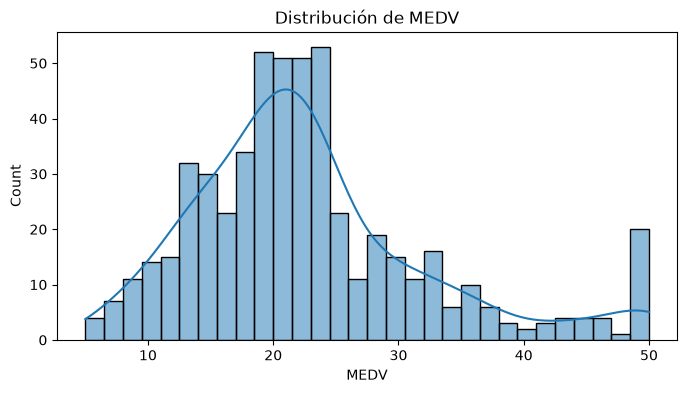

In [22]:
plt.figure(figsize=(8, 4))
sns.histplot(data_orig['MEDV'], kde=True, bins=30)
plt.title('Distribución de MEDV')
plt.show()

Los datos naturalmente presentan una distribucion practicamente normal, el problema es que hay un truncamiento en 50, este es el maximo valor presentado en el dataset, por lo que es evidente que a las casas que valian mas de 50 (y permitian que la distribucion sea simetrica) se les asigno 50 por defecto

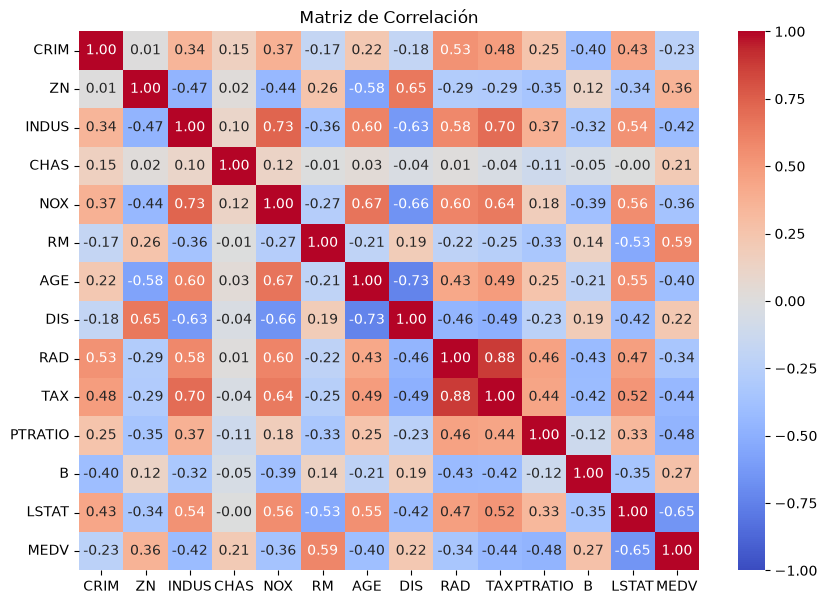

In [23]:
plt.figure(figsize=(10, 7))
sns.heatmap(data_orig.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación')
plt.show()

Multicolinealidad: hay una alta correlacion entre RAD y TAX (r=0.88), por lo que es probable que aporten la misma informacion


Relacion alta con MEDV (target): RM tiene una alta relacion positiva (r=0.59) y LSTAT una alta relacion negativa (r=-0.65)

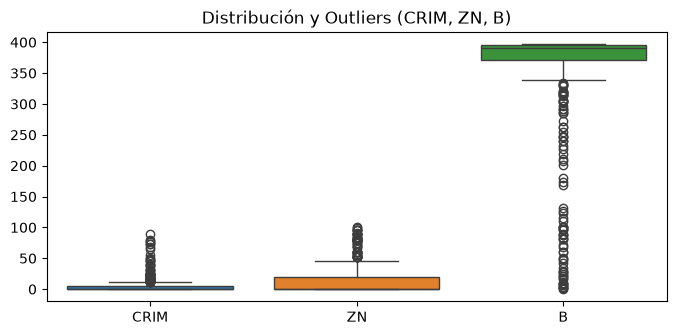

In [24]:
plt.figure(figsize=(8, 3.5))
sns.boxplot(data=data_orig[['CRIM', 'ZN', 'B']])
plt.title('Distribución y Outliers (CRIM, ZN, B)')
plt.show()

Existen 3 variables con extrem asimetria y colas largas, lo que indica que no seria optimo rellenar los nulos con la media, ya que esta sesgada. Utilizar la mediana es una mejor alternativa

*Separacion de datos en train y test*

In [48]:
from sklearn.model_selection import train_test_split
X = data_orig.drop('MEDV', axis=1)
y = data_orig['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)  


(428, 13) (107, 13) (428,) (107,)


*Escalado e imputación de datos*

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


# Crear el pipeline de procesamiento + modelo
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# Ajustado de train
pipeline.fit(X_train, y_train)

# Evaluación en Test (aplica automáticamente transform() a los transformers)
y_pred = pipeline.predict(X_test)



In [ ]:
### Comprobación de correcto funcionamiento del pipeline ###

# Comprobar que no hay valores nulos en el resultado
print("¿Hay nulos en las predicciones?:", np.isnan(y_pred).any())

# Comprobar la cantidad de predicciones 
print("Cantidad de predicciones:", len(y_pred))

¿Hay nulos en las predicciones?: False
Cantidad de predicciones: 107


-ignorar-

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn import svm


X = data_orig.drop(columns="MEDV")
y= data_orig["MEDV"]
# Definir el modelo
clf = svm.SVC(kernel='linear', C=1, random_state=42)

# Ejecutar la validación cruzada
scores = cross_val_score(clf, X, y, cv=5)

# Ver resultados
print(f"Resultados por pliegue: {scores}")
print(f"Precisión media: {scores.mean():.2f} (+/- {scores.std():.2f})")